# Image Search Toolkit

A collection of search & organization methods for a folder of images, combining **CLIP** (semantic) and **pixel-based** (visual) approaches.

**Methods included**

1. Text → image search  
2. Image → image search  
3. Multi-query with negatives  
4. Concept axes (e.g. dark ↔ bright, empty ↔ crowded)  
5. Clustering by meaning (HDBSCAN + auto-labels)  
6. 2D semantic map (UMAP of CLIP embeddings)  
7. Sort by brightness (pixel-based)  
8. Sort by hue / 2D color plane  
9. Sort by visual complexity  
10. Faceted search (text + color + brightness)  
11. Odd one out  

All embeddings are computed once and cached to disk.

## 1. Install dependencies

Run once. On Apple Silicon, PyTorch will use the MPS backend automatically.

In [7]:
!pip install torch torchvision open_clip_torch pillow numpy scikit-learn umap-learn hdbscan matplotlib tqdm ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 47.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 47.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 33.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 63.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [open_clip_torch] [open_clip_torch]


## 2. Imports & config

In [14]:
import os
cache_dir = os.path.abspath('./hf_cache')
os.makedirs(cache_dir, exist_ok=True)

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED, cache_dir=cache_dir,
)
model = model.to(device).eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

import hashlib, pickle, math
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import open_clip
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# === EDIT THIS ===
IMAGE_FOLDER = Path('./Pictures')     # folder with your images
CACHE_DIR    = Path('./cache')      # where embeddings are stored
CACHE_DIR.mkdir(exist_ok=True)

# CLIP model — ViT-B/32 is a good speed/quality balance; ViT-L/14 is stronger but slower
MODEL_NAME, PRETRAINED = 'ViT-B-32', 'laion2b_s34b_b79k'

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

device = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')
print('device:', device)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

device: cuda


## 3. Load CLIP

In [16]:
import os
cache_dir = os.path.abspath('./hf_cache')
os.makedirs(cache_dir, exist_ok=True)

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED, cache_dir=cache_dir,
)
model = model.to(device).eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

@torch.no_grad()
def encode_text(texts):
    if isinstance(texts, str):
        texts = [texts]
    tokens = tokenizer(texts).to(device)
    feats = model.encode_text(tokens).float()
    feats /= feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

@torch.no_grad()
def encode_images(pil_images):
    batch = torch.stack([preprocess(im) for im in pil_images]).to(device)
    feats = model.encode_image(batch).float()
    feats /= feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

## 4. Scan folder + compute/cache embeddings

Cache key depends on folder path, file list, and file sizes — edit a file and it recomputes automatically.

In [20]:
def list_images(folder):
    return sorted([p for p in Path(folder).rglob('*') if p.suffix.lower() in IMG_EXTS])

def cache_key(paths):
    h = hashlib.md5()
    for p in paths:
        h.update(str(p).encode())
        try:
            h.update(str(p.stat().st_size).encode())
        except FileNotFoundError:
            pass
    h.update(MODEL_NAME.encode())
    return h.hexdigest()[:16]

def compute_pixel_features(pil):
    """brightness (0-1), dominant hue (0-1), saturation (0-1), complexity (0-1-ish)."""
    small = pil.convert('RGB').resize((64, 64))
    arr = np.asarray(small).astype(np.float32) / 255.0
    brightness = float(0.2126*arr[..., 0].mean() + 0.7152*arr[..., 1].mean() + 0.0722*arr[..., 2].mean())
    hsv = np.asarray(small.convert('HSV')).astype(np.float32) / 255.0
    weights = hsv[..., 1].flatten() + 1e-6
    hues = hsv[..., 0].flatten()
    angles = hues * 2*np.pi
    x = np.average(np.cos(angles), weights=weights)
    y = np.average(np.sin(angles), weights=weights)
    hue = (math.atan2(y, x) / (2*np.pi)) % 1.0
    sat = float(hsv[..., 1].mean())
    gray = arr.mean(-1)
    gx = np.abs(np.diff(gray, axis=1))   # (64, 63)
    gy = np.abs(np.diff(gray, axis=0))   # (63, 64)
    complexity = float((gx.mean() + gy.mean()) / 2)
    return brightness, hue, sat, complexity

def build_index(folder, batch_size=32):
    paths = list_images(folder)
    if not paths:
        raise RuntimeError(f'No images found in {folder}')
    key = cache_key(paths)
    cache_file = CACHE_DIR / f'index_{key}.pkl'
    if cache_file.exists():
        print(f'loading cached index: {cache_file.name}')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    print(f'computing embeddings for {len(paths)} images...')
    embs, pix = [], []
    valid_paths = []
    for i in tqdm(range(0, len(paths), batch_size)):
        chunk = paths[i:i+batch_size]
        imgs = []
        for p in chunk:
            try:
                im = Image.open(p).convert('RGB')
                imgs.append(im)
                pix.append(compute_pixel_features(im))
                valid_paths.append(p)
            except Exception as e:
                print('skip', p, e)
        if imgs:
            embs.append(encode_images(imgs))
    index = {
        'paths': valid_paths,
        'embeddings': np.vstack(embs),
        'pixel_feats': np.array(pix),
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(index, f)
    print(f'cached to {cache_file}')
    return index

# clear stale cache from the buggy run
import shutil
shutil.rmtree(CACHE_DIR, ignore_errors=True)
CACHE_DIR.mkdir(exist_ok=True)

index = build_index(IMAGE_FOLDER)
paths      = index['paths']
embeddings = index['embeddings']
pixel_feats= index['pixel_feats']
print('images:', len(paths), '| embedding dim:', embeddings.shape[1])

computing embeddings for 7 images...


  0%|          | 0/1 [00:00<?, ?it/s]

cached to cache/index_28ab5c145246b7b3.pkl
images: 7 | embedding dim: 512


## 5. Grid display helper

In [21]:
def show_grid(image_paths, titles=None, cols=5, thumb=180, figtitle=None):
    n = len(image_paths)
    if n == 0:
        print('(no results)')
        return
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*thumb/60, rows*thumb/60))
    axes = np.array(axes).reshape(rows, cols)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            try:
                im = Image.open(image_paths[i]).convert('RGB')
                im.thumbnail((thumb, thumb))
                ax.imshow(im)
                if titles is not None:
                    ax.set_title(str(titles[i])[:40], fontsize=8)
            except Exception as e:
                ax.set_title('err', fontsize=8)
    if figtitle:
        fig.suptitle(figtitle, fontsize=12)
    plt.tight_layout()
    plt.show()

## Method 1 — Text → image search
Encode a text prompt and rank images by cosine similarity.

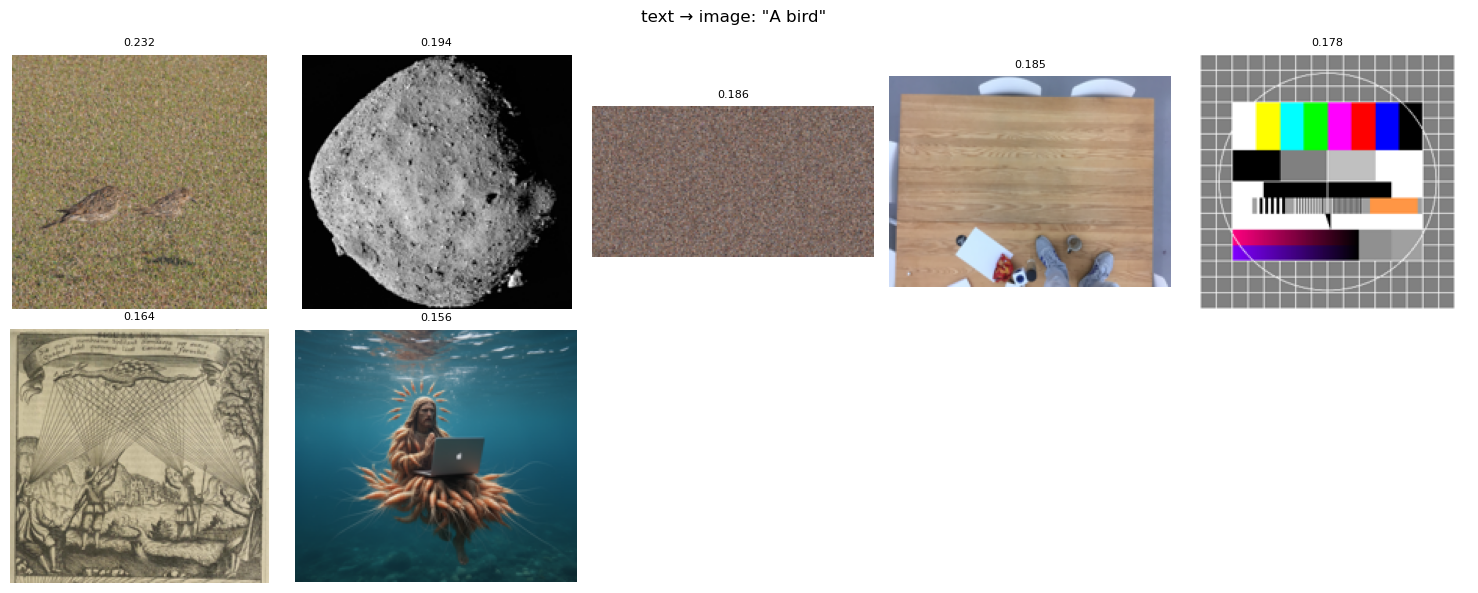

In [29]:
def text_search(query, top_k=10):
    q = encode_text(query)[0]
    sims = embeddings @ q
    idx = np.argsort(-sims)[:top_k]
    return idx, sims[idx]

query = 'A bird'
idx, scores = text_search(query, top_k=10)
show_grid([paths[i] for i in idx],
          titles=[f'{s:.3f}' for s in scores],
          figtitle=f'text → image: "{query}"')

## Method 2 — Image → image search
Pick an image in the folder, rank others by embedding distance.

In [27]:
import io
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept='image/*', multiple=False, description='Upload query')
run_btn  = widgets.Button(description='Find similar', button_style='primary')
out      = widgets.Output()

def similar_to_image(pil_img, top_k=10):
    q = encode_images([pil_img])[0]
    sims = embeddings @ q
    idx = np.argsort(-sims)[:top_k]
    return idx, sims[idx]

def on_click(_):
    out.clear_output()
    with out:
        if not uploader.value:
            print('Please upload an image first.')
            return
        # ipywidgets >=8 returns a tuple of dicts; <8 returns a dict
        item = uploader.value[0] if isinstance(uploader.value, tuple) else next(iter(uploader.value.values()))
        data = item['content']
        query_img = Image.open(io.BytesIO(data)).convert('RGB')
        idx, scores = similar_to_image(query_img, top_k=10)
        # show the uploaded query alongside results
        fig, ax = plt.subplots(figsize=(2.5, 2.5))
        ax.imshow(query_img); ax.axis('off'); ax.set_title('QUERY', fontsize=9)
        plt.show()
        show_grid([paths[i] for i in idx],
                  titles=[f'{s:.3f}' for s in scores],
                  figtitle='most similar in folder')

run_btn.on_click(on_click)
display(widgets.VBox([uploader, run_btn, out]))

## Method 3 — Multi-query with negatives
Add positive prompts together, subtract negatives. Pure vector arithmetic on the text side.

In [ ]:
def multi_query(positives, negatives=None, top_k=10):
    pos = encode_text(positives).mean(axis=0)
    vec = pos
    if negatives:
        neg = encode_text(negatives).mean(axis=0)
        vec = pos - neg
    vec /= np.linalg.norm(vec) + 1e-9
    sims = embeddings @ vec
    idx = np.argsort(-sims)[:top_k]
    return idx, sims[idx]

idx, scores = multi_query(
    positives=['a city street', 'architecture'],
    negatives=['people', 'cars'],
    top_k=10,
)
show_grid([paths[i] for i in idx],
          titles=[f'{s:.3f}' for s in scores],
          figtitle='city+architecture − people−cars')

## Method 4 — Concept axes
Define an axis as `embed(positive) − embed(negative)`, project all images onto it, sort linearly. Works for any bipolar concept.

In [ ]:
def concept_axis(pos_prompt, neg_prompt):
    v = encode_text(pos_prompt)[0] - encode_text(neg_prompt)[0]
    v /= np.linalg.norm(v) + 1e-9
    return embeddings @ v   # one scalar per image

def show_axis(pos, neg, n=12):
    proj = concept_axis(pos, neg)
    order = np.argsort(proj)
    picks = np.linspace(0, len(order)-1, n).astype(int)
    selected = [order[i] for i in picks]
    show_grid([paths[i] for i in selected],
              titles=[f'{proj[i]:+.2f}' for i in selected],
              cols=n, thumb=140,
              figtitle=f'{neg}  ←———————→  {pos}')

show_axis('bright daylight', 'dark night')
show_axis('empty landscape', 'crowded place')
show_axis('natural', 'industrial')
show_axis('warm colors', 'cool colors')

## Method 5 — Clustering by meaning (HDBSCAN + auto-labels)
HDBSCAN discovers cluster count on its own and marks outliers as `-1`. Each cluster is labeled by the text prompt from a small vocabulary whose embedding is closest to the centroid.

In [ ]:
import hdbscan
from sklearn.preprocessing import normalize

# vocabulary for auto-labeling — edit to taste
VOCAB = [
    'portrait of a person', 'landscape', 'forest', 'mountain', 'ocean', 'beach',
    'city street', 'building', 'interior of a room', 'food', 'animal', 'bird',
    'flower', 'machine', 'text document', 'abstract pattern', 'sky', 'night scene',
    'vehicle', 'crowd of people', 'artwork', 'diagram', 'close-up macro',
]
vocab_emb = encode_text(VOCAB)

def cluster_images(min_cluster_size=5):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean')
    labels = clusterer.fit_predict(normalize(embeddings))
    return labels

def label_cluster(member_indices):
    centroid = embeddings[member_indices].mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-9
    sims = vocab_emb @ centroid
    return VOCAB[int(np.argmax(sims))]

labels = cluster_images(min_cluster_size=max(3, len(paths)//50))
unique = sorted(set(labels) - {-1})
print(f'{len(unique)} clusters, {(labels==-1).sum()} outliers')

for c in unique:
    members = np.where(labels == c)[0]
    name = label_cluster(members)
    sample = members[:8]
    show_grid([paths[i] for i in sample],
              cols=8, thumb=140,
              figtitle=f'cluster {c} — "{name}" ({len(members)} images)')

## Method 6 — 2D semantic map (UMAP)
Reduce CLIP embeddings to 2D and plot thumbnails in place. Nearby = semantically similar.

In [ ]:
import umap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
coords2d = reducer.fit_transform(embeddings)

def plot_thumbnail_map(coords, image_paths, thumb=40, figsize=(14, 14), labels=None):
    fig, ax = plt.subplots(figsize=figsize)
    if labels is not None:
        ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab20', s=12, alpha=0.4)
    for (x, y), p in zip(coords, image_paths):
        try:
            im = Image.open(p).convert('RGB')
            im.thumbnail((thumb, thumb))
            ab = AnnotationBbox(OffsetImage(im), (x, y), frameon=False, pad=0)
            ax.add_artist(ab)
        except Exception:
            pass
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('semantic map (UMAP of CLIP embeddings)')
    plt.tight_layout(); plt.show()

plot_thumbnail_map(coords2d, paths, thumb=48, labels=labels)

## Method 7 — Sort by brightness (pixel-based)
Uses the precomputed luminance. Good contrast vs. the CLIP `dark↔bright` axis — often they disagree, which is the interesting part.

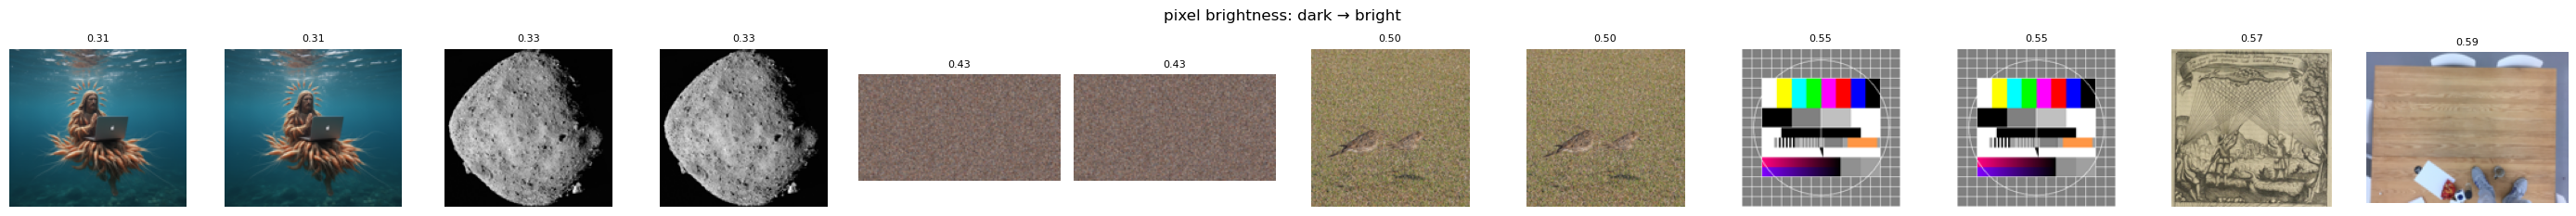

In [25]:
brightness = pixel_feats[:, 0]
order = np.argsort(brightness)
picks = np.linspace(0, len(order)-1, 12).astype(int)
selected = [order[i] for i in picks]
show_grid([paths[i] for i in selected],
          titles=[f'{brightness[i]:.2f}' for i in selected],
          cols=12, thumb=140,
          figtitle='pixel brightness: dark → bright')

## Method 8 — Sort by hue / 2D color plane

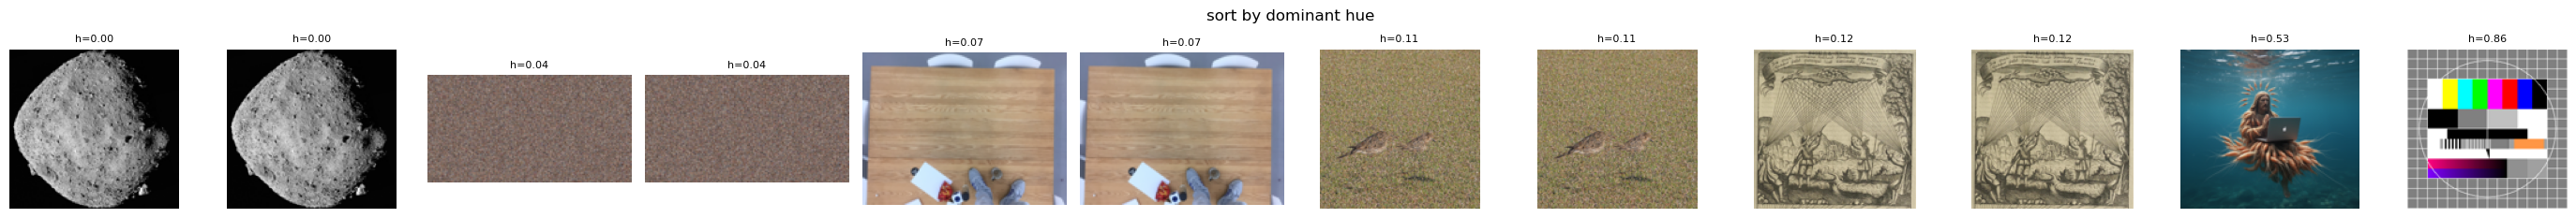

NameError: name 'plot_thumbnail_map' is not defined

In [26]:
hue, sat = pixel_feats[:, 1], pixel_feats[:, 2]

# linear sort by hue
order = np.argsort(hue)
picks = np.linspace(0, len(order)-1, 12).astype(int)
selected = [order[i] for i in picks]
show_grid([paths[i] for i in selected],
          titles=[f'h={hue[i]:.2f}' for i in selected],
          cols=12, thumb=140,
          figtitle='sort by dominant hue')

# 2D: hue angle on color wheel, saturation as radius
angles = hue * 2*np.pi
xs = sat * np.cos(angles)
ys = sat * np.sin(angles)
plot_thumbnail_map(np.column_stack([xs, ys]), paths, thumb=44, figsize=(12, 12))

## Method 9 — Sort by visual complexity

In [ ]:
complexity = pixel_feats[:, 3]
order = np.argsort(complexity)
picks = np.linspace(0, len(order)-1, 12).astype(int)
selected = [order[i] for i in picks]
show_grid([paths[i] for i in selected],
          titles=[f'{complexity[i]:.3f}' for i in selected],
          cols=12, thumb=140,
          figtitle='simple → busy (edge density)')

## Method 10 — Faceted search
Combine a CLIP text query with pixel filters (brightness range, hue range).

In [ ]:
def faceted_search(query, top_k=10,
                   brightness_range=(0.0, 1.0),
                   hue_range=None,   # e.g. (0.0, 0.15) for reds
                   min_saturation=0.0):
    q = encode_text(query)[0]
    sims = embeddings @ q
    mask = ((pixel_feats[:, 0] >= brightness_range[0]) &
            (pixel_feats[:, 0] <= brightness_range[1]) &
            (pixel_feats[:, 2] >= min_saturation))
    if hue_range is not None:
        h = pixel_feats[:, 1]
        lo, hi = hue_range
        if lo <= hi:
            mask &= (h >= lo) & (h <= hi)
        else:  # wraparound, e.g. (0.95, 0.05)
            mask &= (h >= lo) | (h <= hi)
    sims = np.where(mask, sims, -np.inf)
    idx = np.argsort(-sims)[:top_k]
    idx = [i for i in idx if np.isfinite(sims[i])]
    return idx, sims[idx]

idx, scores = faceted_search(
    'a portrait',
    brightness_range=(0.0, 0.4),    # only dark images
    min_saturation=0.1,
    top_k=10,
)
show_grid([paths[i] for i in idx],
          titles=[f'{s:.3f}' for s in scores],
          figtitle='facet: "portrait" + dark + saturated')

## Method 11 — Odd one out
For a given cluster (or any subset), find the member furthest from the centroid. Useful for curation.

In [ ]:
def odd_one_out(indices, n=3):
    sub = embeddings[indices]
    centroid = sub.mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-9
    sims = sub @ centroid
    order = np.argsort(sims)  # lowest sim first = most odd
    return [indices[i] for i in order[:n]], sims[order[:n]]

# example: run on the first non-noise cluster
if len(unique):
    members = np.where(labels == unique[0])[0]
    odd, scores = odd_one_out(list(members), n=5)
    show_grid([paths[i] for i in odd],
              titles=[f'{s:.3f}' for s in scores],
              figtitle=f'most unusual members of cluster {unique[0]}')

## Next steps

- Wrap any of these in `ipywidgets` (text box + slider) for an interactive UI inside the notebook.
- For a standalone web UI, port the same functions to **Gradio** — ~20 lines gets you a browseable search page.
- For large folders (>10k), replace `embeddings @ q` with a FAISS index for sub-millisecond search.
- Try **ViT-L-14** (`pretrained='laion2b_s32b_b82k'`) for noticeably better semantics at ~3× the compute.